# Understanding the Bar Chart

A bar chart maps each **category** to a bar whose height (or length) encodes a quantity — count, proportion, mean, or any aggregate. It is the standard tool for comparing values across discrete groups.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

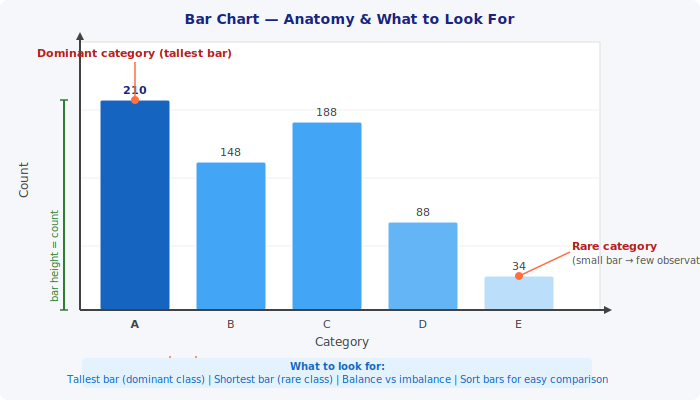

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="400"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="400" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Bar Chart — Anatomy &amp; What to Look For</text>

  <!-- plot area -->
  <rect x="80" y="42" width="520" height="268" fill="white" stroke="#E0E0E0"/>

  <!-- gridlines -->
  <line x1="80" y1="110" x2="600" y2="110" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="80" y1="178" x2="600" y2="178" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="80" y1="246" x2="600" y2="246" stroke="#F0F0F0" stroke-width="1"/>

  <!-- bars: 5 categories, barW=70, gap=26, step=96 -->
  <!-- bar A (tallest, highlighted) x=100 h=210 -->
  <rect x="100" y="100" width="70" height="210" fill="#1565C0" stroke="white" stroke-width="1" rx="2"/>
  <!-- bar B x=196 h=148 -->
  <rect x="196" y="162" width="70" height="148" fill="#42A5F5" stroke="white" stroke-width="1" rx="2"/>
  <!-- bar C x=292 h=188 -->
  <rect x="292" y="122" width="70" height="188" fill="#42A5F5" stroke="white" stroke-width="1" rx="2"/>
  <!-- bar D x=388 h=88 -->
  <rect x="388" y="222" width="70" height="88" fill="#64B5F6" stroke="white" stroke-width="1" rx="2"/>
  <!-- bar E (rare) x=484 h=34 -->
  <rect x="484" y="276" width="70" height="34" fill="#BBDEFB" stroke="white" stroke-width="1" rx="2"/>

  <!-- count labels on top of bars -->
  <text x="135" y="94"  text-anchor="middle" font-size="11" font-weight="bold" fill="#1A237E">210</text>
  <text x="231" y="156" text-anchor="middle" font-size="11" fill="#424242">148</text>
  <text x="327" y="116" text-anchor="middle" font-size="11" fill="#424242">188</text>
  <text x="423" y="216" text-anchor="middle" font-size="11" fill="#424242">88</text>
  <text x="519" y="270" text-anchor="middle" font-size="11" fill="#424242">34</text>

  <!-- category labels -->
  <text x="135" y="328" text-anchor="middle" font-size="11" fill="#424242" font-weight="bold">A</text>
  <text x="231" y="328" text-anchor="middle" font-size="11" fill="#424242">B</text>
  <text x="327" y="328" text-anchor="middle" font-size="11" fill="#424242">C</text>
  <text x="423" y="328" text-anchor="middle" font-size="11" fill="#424242">D</text>
  <text x="519" y="328" text-anchor="middle" font-size="11" fill="#424242">E</text>

  <!-- axes -->
  <line x1="80" y1="310" x2="604" y2="310" stroke="#424242" stroke-width="2"/>
  <line x1="80" y1="310" x2="80"  y2="40"  stroke="#424242" stroke-width="2"/>
  <polygon points="604,306 612,310 604,314" fill="#424242"/>
  <polygon points="76,40 80,32 84,40" fill="#424242"/>
  <text x="342" y="346" text-anchor="middle" font-size="12" fill="#424242">Category</text>
  <text x="28" y="180" text-anchor="middle" font-size="12" fill="#424242"
        transform="rotate(-90 28 180)">Count</text>

  <!-- ── ANNOTATIONS ── -->

  <!-- Dominant category -->
  <line x1="135" y1="100" x2="135" y2="62" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="135" cy="100" r="4" fill="#FF7043"/>
  <text x="135" y="57" text-anchor="middle" font-size="11" font-weight="bold" fill="#B71C1C">Dominant category (tallest bar)</text>

  <!-- Rare category -->
  <line x1="519" y1="276" x2="570" y2="252" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="519" cy="276" r="4" fill="#FF7043"/>
  <text x="572" y="250" font-size="11" font-weight="bold" fill="#B71C1C">Rare category</text>
  <text x="572" y="264" font-size="10" fill="#555">(small bar → few observations)</text>

  <!-- Bar height = count -->
  <line x1="64" y1="100" x2="64" y2="310" stroke="#2E7D32" stroke-width="2"/>
  <line x1="60" y1="100" x2="68" y2="100" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="60" y1="310" x2="68" y2="310" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="58" y="210" text-anchor="end" font-size="10" fill="#2E7D32" transform="rotate(-90 58 210)">bar height = count</text>

  <!-- Gap between bars -->
  <line x1="170" y1="360" x2="196" y2="360" stroke="#FF7043" stroke-width="1.5"/>
  <line x1="170" y1="356" x2="170" y2="364" stroke="#FF7043" stroke-width="1.5"/>
  <line x1="196" y1="356" x2="196" y2="364" stroke="#FF7043" stroke-width="1.5"/>
  <text x="183" y="378" text-anchor="middle" font-size="10" fill="#B71C1C">gap</text>

  <!-- Ordered note -->
  <rect x="82" y="358" width="510" height="30" fill="#E3F2FD" rx="4"/>
  <text x="337" y="370" text-anchor="middle" font-size="10" fill="#1565C0" font-weight="bold">What to look for:</text>
  <text x="337" y="383" text-anchor="middle" font-size="10" fill="#1565C0">Tallest bar (dominant class)  |  Shortest bar (rare class)  |  Balance vs imbalance  |  Sort bars for easy comparison</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Bar Chart

| Feature | What it tells you |
|---|---|
| **Tallest bar** | Dominant category — most frequent value or highest aggregate |
| **Very short bar** | Rare category — may need grouping into "Other" |
| **All bars roughly equal** | Balanced distribution |
| **One bar dominates** | Class imbalance — important for ML models |
| **Sorted bars** | Easier to rank and compare |
| **Horizontal bars** | Better when category labels are long |

**Grouped vs stacked bars**: Use *grouped* bars to compare two groups side by side. Use *stacked* bars to show how sub-categories sum to a total.

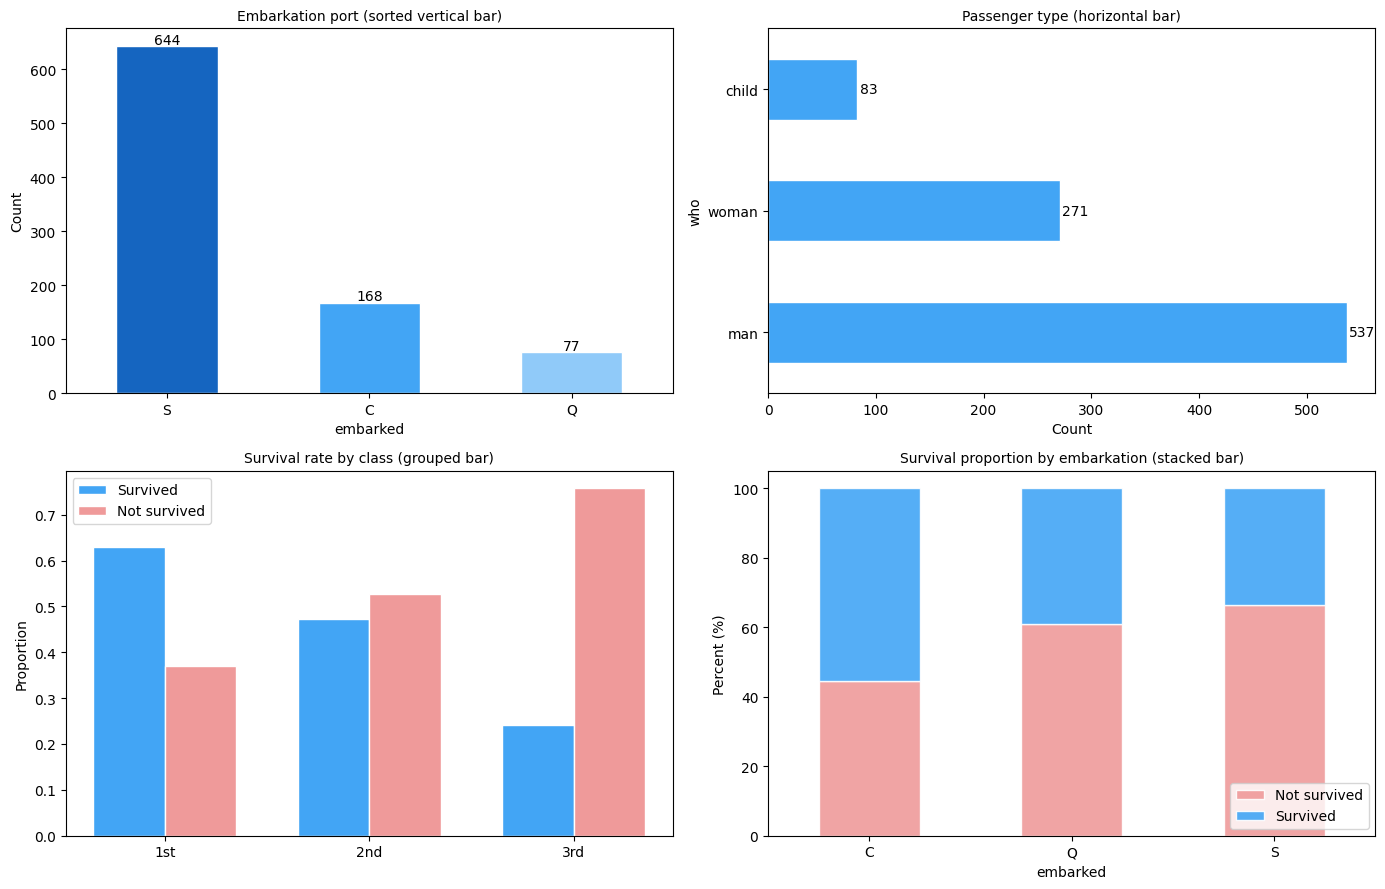

In [3]:
df = sns.load_dataset('titanic')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Vertical bar — sorted by count
counts = df['embarked'].value_counts()
counts.plot(kind='bar', ax=axes[0,0], color=['#1565C0','#42A5F5','#90CAF9'],
            edgecolor='white')
for i, v in enumerate(counts):
    axes[0,0].text(i, v + 4, str(v), ha='center', fontsize=10)
axes[0,0].set_title('Embarkation port (sorted vertical bar)', fontsize=10)
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Horizontal bar — long category names
counts2 = df['who'].value_counts()
counts2.plot(kind='barh', ax=axes[0,1], color='#42A5F5', edgecolor='white')
for i, v in enumerate(counts2):
    axes[0,1].text(v + 2, i, str(v), va='center', fontsize=10)
axes[0,1].set_title('Passenger type (horizontal bar)', fontsize=10)
axes[0,1].set_xlabel('Count')

# Grouped bar: survival rate by class
surv_rate = df.groupby('pclass')['survived'].mean().reset_index()
surv_rate['not_survived'] = 1 - surv_rate['survived']
x = np.arange(len(surv_rate))
w = 0.35
axes[1,0].bar(x - w/2, surv_rate['survived'],     w, label='Survived',     color='#42A5F5', edgecolor='white')
axes[1,0].bar(x + w/2, surv_rate['not_survived'], w, label='Not survived', color='#EF9A9A', edgecolor='white')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(['1st', '2nd', '3rd'])
axes[1,0].set_title('Survival rate by class (grouped bar)', fontsize=10)
axes[1,0].set_ylabel('Proportion')
axes[1,0].legend()

# Stacked bar: embark port by survival
ct = pd.crosstab(df['embarked'], df['survived'], normalize='index') * 100
ct.columns = ['Not survived', 'Survived']
ct.plot(kind='bar', stacked=True, ax=axes[1,1],
        color=['#EF9A9A','#42A5F5'], edgecolor='white', alpha=0.9)
axes[1,1].set_title('Survival proportion by embarkation (stacked bar)', fontsize=10)
axes[1,1].set_ylabel('Percent (%)')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Comparing counts or aggregates across categories |
| **Sort bars** | Descending sort makes ranking obvious |
| **Horizontal** | Use when labels are long |
| **Grouped** | Compare two groups side by side |
| **Stacked** | Show how sub-categories compose a total |
| **Class imbalance** | One very tall bar + many short bars → models will be biased |